In [33]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report
import random
import numpy as np

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [35]:
train_path = "Teeth_Dataset/Training"
val_path = "Teeth_Dataset/Validation"
test_path = "Teeth_Dataset/Testing"

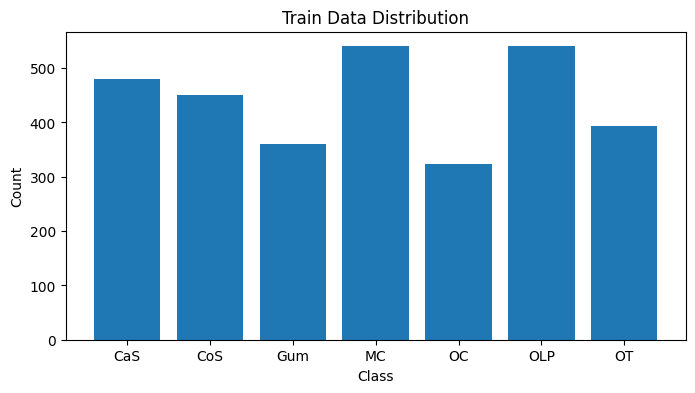

In [36]:
classes = os.listdir(train_path)
counts = []
for c in classes:
    counts.append(len(os.listdir(os.path.join(train_path, c))))

plt.figure(figsize=(8, 4))
plt.bar(classes, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Train Data Distribution")
plt.show()

In [37]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [38]:
train_data = ImageFolder(root=train_path, transform=train_transform)
val_data = ImageFolder(root=val_path, transform=test_transform)
test_data = ImageFolder(root=test_path, transform=test_transform)

In [39]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [42]:
conv_layers = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
)

dummy_input = torch.zeros(1, 3, 128, 128)
flattened_size = conv_layers(dummy_input).view(1, -1).shape[1]

model = nn.Sequential(
    conv_layers,
    nn.Flatten(),
    nn.Linear(flattened_size, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, len(train_data.classes))
)

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

from collections import Counter
class_counts = Counter(train_data.targets)
total_samples = sum(class_counts.values())
class_weights = [total_samples / class_counts[i] for i in range(len(train_data.classes))]
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

epochs = 50

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [45]:
best_val_loss = float("inf")
patience = 5
patience_counter = 0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct / total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    epoch_val_loss = val_running_loss / len(val_loader)
    epoch_val_acc = 100 * val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    scheduler.step()

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

Epoch 1/50 | Train Loss: 1.5216 | Train Acc: 39.59% | Val Loss: 1.4898 | Val Acc: 41.73%
Epoch 2/50 | Train Loss: 1.4208 | Train Acc: 44.51% | Val Loss: 1.2776 | Val Acc: 52.72%
Epoch 3/50 | Train Loss: 1.3574 | Train Acc: 47.23% | Val Loss: 1.4028 | Val Acc: 47.47%
Epoch 4/50 | Train Loss: 1.2685 | Train Acc: 50.08% | Val Loss: 1.1380 | Val Acc: 59.53%
Epoch 5/50 | Train Loss: 1.1817 | Train Acc: 54.75% | Val Loss: 1.0404 | Val Acc: 60.41%
Epoch 6/50 | Train Loss: 1.0957 | Train Acc: 57.53% | Val Loss: 0.9651 | Val Acc: 64.20%
Epoch 7/50 | Train Loss: 1.0436 | Train Acc: 59.09% | Val Loss: 0.8694 | Val Acc: 66.54%
Epoch 8/50 | Train Loss: 0.9602 | Train Acc: 63.95% | Val Loss: 0.8149 | Val Acc: 71.79%
Epoch 9/50 | Train Loss: 0.9160 | Train Acc: 64.37% | Val Loss: 0.7857 | Val Acc: 72.47%
Epoch 10/50 | Train Loss: 0.8181 | Train Acc: 69.65% | Val Loss: 0.6773 | Val Acc: 75.29%
Epoch 11/50 | Train Loss: 0.7510 | Train Acc: 70.94% | Val Loss: 0.6894 | Val Acc: 74.42%
Epoch 12/50 | Train

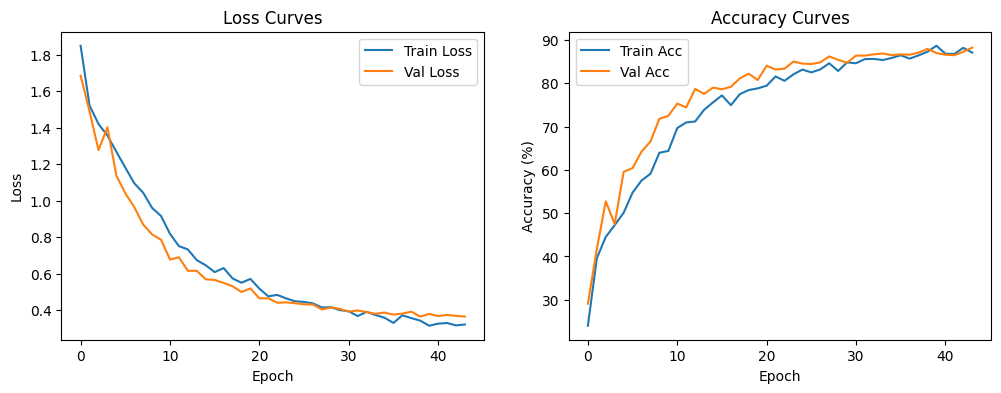

In [46]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curves")

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(val_accuracies, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Accuracy Curves")

plt.show()

In [47]:
model.eval()
test_preds = []
test_targets = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        
        test_preds.extend(predicted.cpu().numpy())
        test_targets.extend(labels.cpu().numpy())

In [48]:
print(classification_report(test_targets, test_preds, target_names=train_data.classes))

              precision    recall  f1-score   support

         CaS       0.88      0.85      0.86       160
         CoS       0.91      0.92      0.91       149
         Gum       0.89      0.91      0.90       120
          MC       0.88      0.87      0.87       180
          OC       0.84      0.85      0.85       108
         OLP       0.83      0.80      0.82       180
          OT       0.88      0.93      0.90       131

    accuracy                           0.87      1028
   macro avg       0.87      0.88      0.87      1028
weighted avg       0.87      0.87      0.87      1028

